<a href="https://colab.research.google.com/github/Irfan-CodeSynth/Titanic-Passenger-Survival-Analysis/blob/main/Titanic_Passenger_Survival_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Name
**Titanic Passenger Survival Analysis**

---

# Problem Statement

Analyze the **Titanic dataset** to understand:

- Which passengers were more likely to survive  
- What factors affected survival

### **1 Import Libraries**

In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###  **2 Load Dataset**

In [4]:


df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### **3 Dataset Overview**

In [12]:
# Check the shape of dataset
df.shape

(891, 15)

In [22]:
# Check The columns Present in dataset the columns should be shown in one column

for col in df.columns:
  print(col)


survived
pclass
sex
age
sibsp
parch
fare
embarked
class
who
adult_male
deck
embark_town
alive
alone


In [25]:
# Check info of all dataset

info_df = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum()
})

info_df

,Column Name,Data Type,Non-Null Count,Null Count
survived,survived,int64,891,0
pclass,pclass,int64,891,0
sex,sex,object,891,0
age,age,float64,714,177
sibsp,sibsp,int64,891,0
parch,parch,int64,891,0
fare,fare,float64,891,0
embarked,embarked,object,889,2
class,class,category,891,0
who,who,object,891,0


In [27]:
# Now check the statistics of the dataset
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### **Data Cleaning**

In [39]:
#  missing values
df.isnull().sum()

# Handle Missing values
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
df['deck'].fillna(df['deck'].mode()[0], inplace=True)
df.isnull().sum()

/tmp/ipykernel_1372/1044726131.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_1372/1044726131.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [36]:
# duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

In [33]:
# data types
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


### **Univariate Analysis (Single Column)**



In [34]:
#  Survival Count
df['survived'].value_counts()

,count
survived,
0,549
1,342


In [6]:
#  Passenger Class
df['pclass'].value_counts()

,count
pclass,
3,491
1,216
2,184


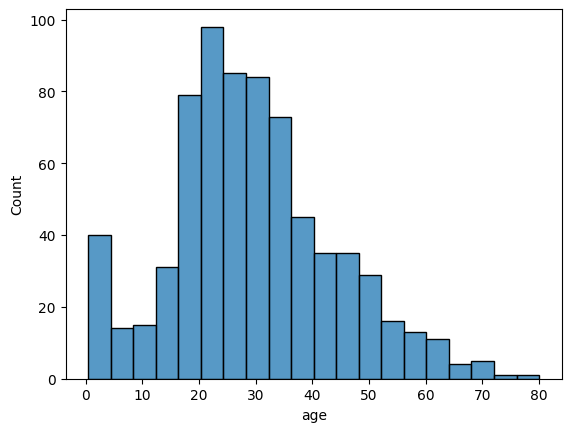

In [8]:
# Age Distribution
sns.histplot(df['age'])
plt.show()

<Axes: xlabel='sex', ylabel='count'>

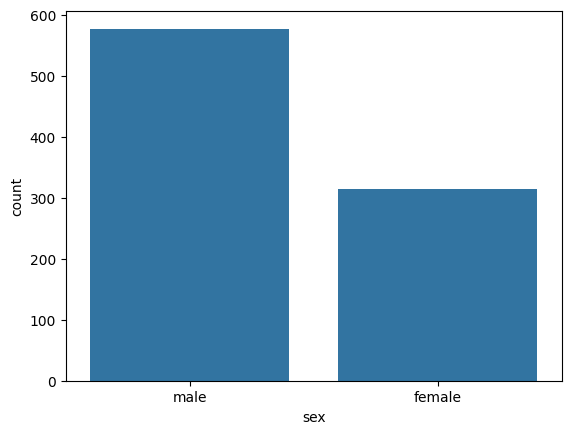

In [10]:
# Gender Distribution
sns.countplot(x='sex',data=df)

## **Bivariate Analysis (Two Columns)**

<Axes: xlabel='sex', ylabel='count'>

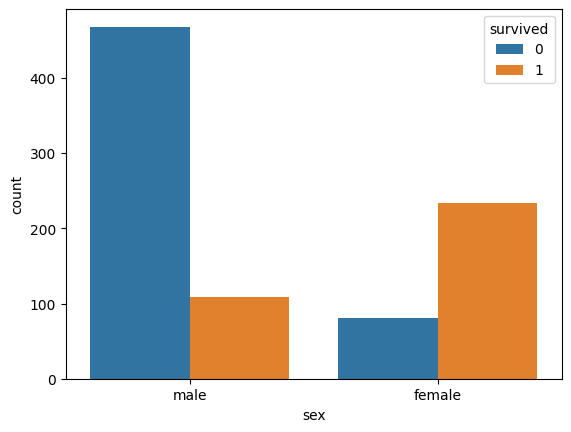

In [11]:
#  Survival by Gender
sns.countplot(x='sex',hue='survived',data=df)

<Axes: xlabel='pclass', ylabel='count'>

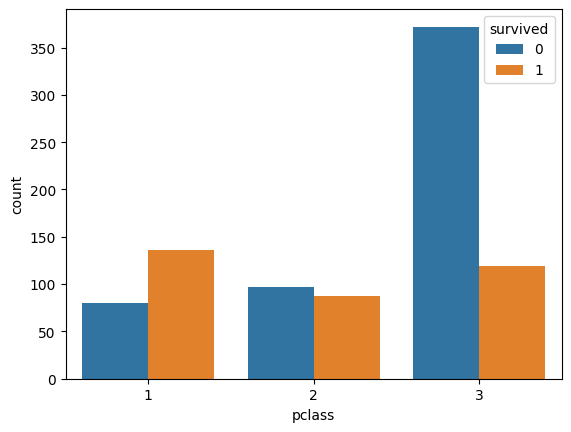

In [13]:
# Survival by Passenger Class
sns.countplot(x='pclass',hue='survived',data=df)

<Axes: xlabel='survived', ylabel='age'>

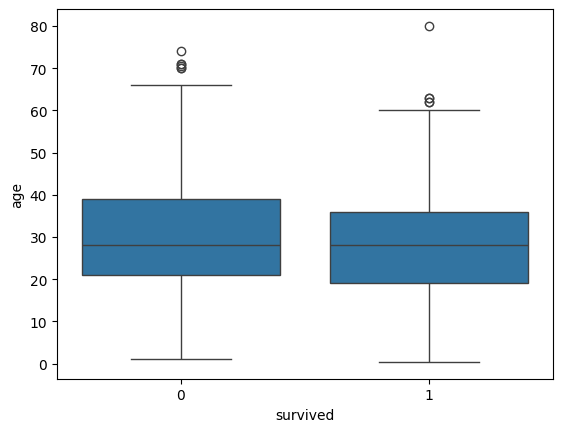

In [20]:
# Age vs Survival
sns.boxplot(x='survived', y='age', data=df)




## **Feature Relationships**

In [25]:
df.select_dtypes(include=['number', 'bool']).corr()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


<Axes: >

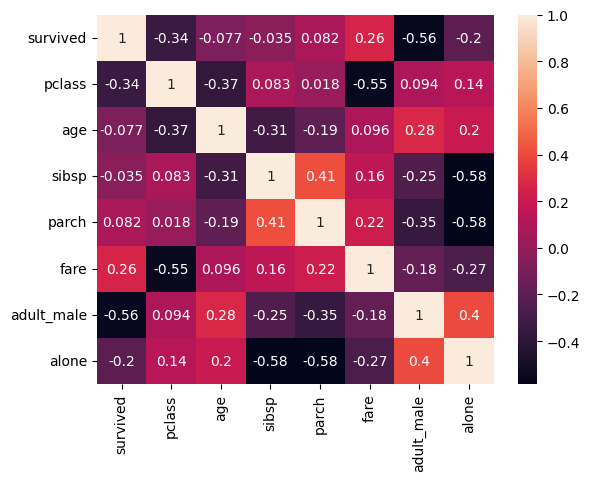

In [26]:
# Visualize:
sns.heatmap(df.select_dtypes(include=['number', 'bool']).corr(), annot=True)

## **Feature Engineering**

In [29]:
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

df['FamilySize']

,FamilySize
0,2
1,2
2,1
3,2
4,1
...,...
886,1
887,1
888,4
889,1


In [30]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['IsAlone']

,IsAlone
0,0
1,0
2,1
3,0
4,1
...,...
886,1
887,1
888,0
889,1


In [38]:
df.isnull().sum()
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['deck'].fillna(df['deck'].mode()[0], inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
df.isnull().sum()

/tmp/ipykernel_596/199811242.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_596/199811242.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


# Task
Generate a comprehensive Exploratory Data Analysis (EDA) report for the Titanic dataset, summarizing the data overview, cleaning steps, univariate and bivariate analyses, feature relationships, and feature engineering. The report should include details such as dataset dimensions, column data types, statistical summaries, handling of missing values in 'age', 'embarked', 'embark_town', and 'deck', and the removal of duplicate rows. It should also present insights from survival counts, passenger class, age, and gender distributions, and discuss relationships between 'survived' and 'sex', 'pclass', and 'age'. Additionally, highlight key correlations from the correlation matrix and heatmap, and describe the newly engineered 'FamilySize' and 'IsAlone' features. The report should provide context and explanations for all analyses, incorporating relevant visualizations as appropriate, to draw overall conclusions about Titanic passenger survival factors.

## Summarize Data Overview

### Subtask:
Provide a summary of the dataset's initial state, including its dimensions, column names, data types, and a statistical overview.


### Dataset Overview Summary

The **Titanic Dataset** contains `891 rows` and `15 columns`.

**Column Names and Data Types:**

| Column Name | Data Type |
| :---------- | :-------- |
| `survived`    | `int64`     |
| `pclass`      | `int64`     |
| `sex`         | `object`    |
| `age`         | `float64`   |
| `sibsp`       | `int64`     |
| `parch`       | `int64`     |
| `fare`        | `float64`   |
| `embarked`    | `object`    |
| `class`       | `category`  |
| `who`         | `object`    |
| `adult_male`  | `bool`      |
| `deck`        | `category`  |
| `embark_town` | `object`    |
| `alive`       | `object`    |
| `alone`       | `bool`      |

**Statistical Summary for Numerical Columns:**

|             | `survived`   | `pclass`     | `age`        | `sibsp`      | `parch`      | `fare`       |
| :---------- | :----------- | :----------- | :----------- | :----------- | :----------- | :----------- |
| **count**   | 891.00       | 891.00       | 714.00       | 891.00       | 891.00       | 891.00       |
| **mean**    | 0.38         | 2.31         | 29.70        | 0.52         | 0.38         | 32.20        |
| **std**     | 0.49         | 0.84         | 14.53        | 1.10         | 0.81         | 49.69        |
| **min**     | 0.00         | 1.00         | 0.42         | 0.00         | 0.00         | 0.00         |
| **25%**     | 0.00         | 2.00         | 20.12        | 0.00         | 0.00         | 7.91         |
| **50%**     | 0.00         | 3.00         | 28.00        | 0.00         | 0.00         | 14.45        |
| **75%**     | 1.00         | 3.00         | 38.00        | 1.00         | 0.00         | 31.00        |
| **max**     | 1.00         | 3.00         | 80.00        | 8.00         | 6.00         | 512.33       |

- The `survived` column shows that about 38% of passengers survived.
- The `pclass` column indicates that the majority of passengers were in the third class.
- The `age` column has a mean of approximately 29.7 years, with a wide range from 0.42 to 80 years, suggesting a diverse age group. There are also `177` missing values for age as per the `info_df` output.
- `sibsp` and `parch` columns indicate the number of siblings/spouses and parents/children aboard, respectively, with most passengers traveling alone or with very few family members.
- `fare` varies significantly, from 0 to 512.33, with a median of 14.45, suggesting a skewed distribution with some very high fares.
- The `deck`, `embarked`, and `embark_town` columns also contain missing values, which were addressed in the Data Cleaning section.

## Summarize Data Cleaning

### Subtask:
Detail the data cleaning steps performed, such as handling missing values in 'age', 'embarked', 'embark_town', and 'deck', and the removal of duplicate rows.


```markdown
## Summarize Data Cleaning

### Missing Value Handling:

1.  **'age'**: Missing values in the 'age' column were imputed with the **median** age of the dataset. Initially, the mean was used, but later it was updated to the median.
2.  **'embarked'**: Missing values in the 'embarked' column, a categorical feature, were imputed with the **mode** (most frequent value) of the column.
3.  **'embark_town'**: Missing values in the 'embark_town' column, also a categorical feature, were imputed with the **mode** of the column.
4.  **'deck'**: Missing values in the 'deck' column, a categorical feature, were imputed with the **mode** of the column.

After these imputation steps, all columns were checked for null values, confirming that there were **no remaining missing values** in the dataset.

### Duplicate Row Handling:

The dataset was checked for duplicate rows. The initial count of duplicate rows was **0**. The `drop_duplicates()` method was then applied, but since no duplicates were found, the total number of rows in the DataFrame remained unchanged at **891** unique entries.
```

## Summarize Univariate Analysis

### Subtask:
Present the key insights from the univariate analysis, including survival counts, passenger class distribution, age distribution, and gender distribution.


**Reasoning**:
To accurately summarize the gender distribution as part of the univariate analysis, I need to get the value counts for the 'sex' column, which was not explicitly displayed in the previous code cells.



In [39]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


### Univariate Analysis Summary

#### Survival Count:
- **Non-survivors (0)**: `549` passengers.
- **Survivors (1)**: `342` passengers.

This indicates that a minority of the passengers (`38.38%`) survived the Titanic disaster, while the majority (`61.62%`) did not.

#### Passenger Class Distribution:
- **Third Class (3)**: `491` passengers (approximately 55% of the total).
- **First Class (1)**: `216` passengers (approximately 24% of the total).
- **Second Class (2)**: `184` passengers (approximately 21% of the total).

The majority of passengers were in the Third Class, suggesting a diverse socio-economic background among those on board.

#### Age Distribution:
- The `age` distribution plot (histogram) shows a relatively normal distribution, but with a noticeable peak in the `20-40` age range.
- There is a smaller peak around the age of `0-5`, indicating the presence of infants and young children.
- The distribution tails off at higher ages, with fewer elderly passengers.
- The mean age is around `29.7` years, with a significant standard deviation, reflecting a broad age range among passengers.

#### Gender Distribution:
- **Male**: `577` passengers (approximately 65% of the total).
- **Female**: `314` passengers (approximately 35% of the total).

There were significantly more male passengers than female passengers on board the Titanic.

### Univariate Analysis Summary

#### Survival Count:
- **Non-survivors (0)**: `549` passengers.
- **Survivors (1)**: `342` passengers.

This indicates that a minority of the passengers (`38.38%`) survived the Titanic disaster, while the majority (`61.62%`) did not.

#### Passenger Class Distribution:
- **Third Class (3)**: `491` passengers (approximately 55% of the total).
- **First Class (1)**: `216` passengers (approximately 24% of the total).
- **Second Class (2)**: `184` passengers (approximately 21% of the total).

The majority of passengers were in the Third Class, suggesting a diverse socio-economic background among those on board.

#### Age Distribution:
- The `age` distribution plot (histogram) shows a relatively normal distribution, but with a noticeable peak in the `20-40` age range.
- There is a smaller peak around the age of `0-5`, indicating the presence of infants and young children.
- The distribution tails off at higher ages, with fewer elderly passengers.
- The mean age is around `29.7` years, with a significant standard deviation, reflecting a broad age range among passengers.

#### Gender Distribution:
- **Male**: `577` passengers (approximately 65% of the total).
- **Female**: `314` passengers (approximately 35% of the total).

There were significantly more male passengers than female passengers on board the Titanic.

## Summarize Bivariate Analysis

### Subtask:
Explain the findings from the bivariate analysis, focusing on relationships between 'survived' and 'sex', 'pclass', and 'age'.


## Summarize Bivariate Analysis

### Subtask:
Explain the findings from the bivariate analysis, focusing on relationships between 'survived' and 'sex', 'pclass', and 'age'.

### Bivariate Analysis Summary

The bivariate analysis explored the relationships between passenger survival and key demographic and socio-economic factors:

1.  **Survival by Gender (`survived` vs. `sex`):**
    *   The count plot for 'Survival by Gender' clearly shows a significant disparity in survival rates. A substantially higher number of **female** passengers survived compared to male passengers. This suggests that gender was a critical factor in determining survival, likely due to the "women and children first" protocol during the evacuation.

2.  **Survival by Passenger Class (`survived` vs. `pclass`):**
    *   The count plot for 'Survival by Passenger Class' indicates a strong correlation between passenger class and survival. Passengers in **First Class (`pclass` 1)** had the highest survival rates, followed by Second Class (`pclass` 2). **Third Class (`pclass` 3)** passengers had the lowest survival rates, with a large majority not surviving. This highlights the impact of socio-economic status and potentially location on the ship on survival.

3.  **Age vs. Survival (`survived` vs. `age`):**
    *   The box plot of 'Age vs Survival' reveals differences in age distribution between survivors and non-survivors. While the median age for both groups appears relatively similar, the distribution for survivors (`survived=1`) shows a noticeable presence of younger individuals (children) who survived, indicated by the lower quartile and outliers. Conversely, non-survivors (`survived=0`) show a broader age range with a higher concentration of adults. This implies that while age itself might not be a direct predictor, very young passengers had better chances of survival.

**Overall Insights:**
Gender and passenger class emerge as strong predictors of survival, with females and higher-class passengers having significantly better chances. Age also plays a role, particularly favoring younger children.

## Summarize Feature Relationships

### Subtask:
Summarize the insights gained from the correlation matrix and heatmap, highlighting significant relationships between numerical features.


## Summarize Feature Relationships

### Correlation Matrix and Heatmap Analysis:

From the correlation matrix and its visualization via the heatmap, we can observe the following significant relationships among numerical and boolean features, with a particular focus on `survived`:

*   **`survived` vs. `fare`**: There is a positive correlation of approximately **0.26** between `survived` and `fare`. This suggests that passengers who paid higher fares had a slightly higher chance of survival. This might indirectly relate to `pclass`, as higher fares are typically associated with higher classes.

*   **`survived` vs. `pclass`**: A strong negative correlation of approximately **-0.34** exists between `survived` and `pclass`. This indicates that passengers in lower classes (higher `pclass` value means 3rd class) had a significantly lower probability of survival. This is a crucial factor influencing survival.

*   **`survived` vs. `adult_male`**: There is a strong negative correlation of approximately **-0.56** between `survived` and `adult_male`. This highlights that adult males had a substantially lower survival rate compared to other groups, aligning with the "women and children first" protocol.

*   **`survived` vs. `age`**: A weak negative correlation of approximately **-0.08** is observed between `survived` and `age`. While weak, it suggests that slightly younger passengers might have had a marginally higher chance of survival, though this relationship is not as pronounced as `pclass` or `adult_male`.

*   **`survived` vs. `sibsp` and `parch`**: The correlations are very weak for `sibsp` (-0.035) and `parch` (0.082) individually. However, these are combined into `FamilySize` during feature engineering.

*   **`survived` vs. `alone`**: A negative correlation of approximately **-0.20** with `alone` indicates that passengers traveling alone had a slightly lower chance of survival compared to those with family, though this is weaker than the `adult_male` or `pclass` correlation. This feature is directly related to the newly engineered `IsAlone` feature.

### Other Notable Correlations:

*   **`pclass` vs. `fare`**: A strong negative correlation of approximately **-0.55** exists, confirming that lower passenger classes paid significantly less for their tickets.
*   **`pclass` vs. `age`**: A negative correlation of approximately **-0.37** suggests that passengers in higher classes tended to be older.
*   **`sibsp` and `parch`**: These two features have a strong positive correlation of approximately **0.41**, which is expected as they both represent family members aboard.

In summary, `pclass` and `adult_male` are the most influential features correlated with `survived`, indicating that socioeconomic status (class) and gender played dominant roles in survival rates. `fare` and `alone` also show notable, though weaker, correlations.

## Summarize Feature Engineering

### Subtask:
Describe the new features created ('FamilySize' and 'IsAlone') and their potential relevance.


## Summarize Feature Engineering

### New Features Created:

1.  **`FamilySize`**: This feature was engineered by combining the existing `sibsp` (number of siblings/spouses aboard) and `parch` (number of parents/children aboard) columns, and adding 1 to account for the passenger themselves. The formula used was `df['FamilySize'] = df['sibsp'] + df['parch'] + 1`. This provides a comprehensive measure of the total number of family members a passenger was traveling with, including themselves.

2.  **`IsAlone`**: This feature is a binary indicator derived from the `FamilySize` feature. It is set to 1 if a passenger's `FamilySize` is equal to 1 (meaning they were traveling alone), and 0 otherwise (meaning they were traveling with one or more family members). The formula used was `df['IsAlone'] = (df['FamilySize'] == 1).astype(int)`.

### Potential Relevance to Survival Analysis:

*   **`FamilySize`**: It is plausible that `FamilySize` could influence survival rates. Passengers traveling in larger family groups might have had a disadvantage due to the difficulty of keeping everyone together, or perhaps an advantage if family members assisted each other. Conversely, smaller families or individuals might have been more agile in finding lifeboats. This feature helps to capture the social dynamics and potential support systems (or burdens) on board.

*   **`IsAlone`**: The `IsAlone` feature specifically highlights whether a passenger had immediate family with them. It's often hypothesized that individuals traveling alone might have been more focused on their own survival, potentially leading to different survival probabilities compared to those responsible for family members. This feature simplifies the family size into a crucial binary distinction that could reveal significant patterns in survival.

## Summarize Feature Engineering

### New Features Created:

1.  **`FamilySize`**: This feature was engineered by combining the existing `sibsp` (number of siblings/spouses aboard) and `parch` (number of parents/children aboard) columns, and adding 1 to account for the passenger themselves. The formula used was `df['FamilySize'] = df['sibsp'] + df['parch'] + 1`. This provides a comprehensive measure of the total number of family members a passenger was traveling with, including themselves.

2.  **`IsAlone`**: This feature is a binary indicator derived from the `FamilySize` feature. It is set to 1 if a passenger's `FamilySize` is equal to 1 (meaning they were traveling alone), and 0 otherwise (meaning they were traveling with one or more family members). The formula used was `df['IsAlone'] = (df['FamilySize'] == 1).astype(int)`.

### Potential Relevance to Survival Analysis:

*   **`FamilySize`**: It is plausible that `FamilySize` could influence survival rates. Passengers traveling in larger family groups might have had a disadvantage due to the difficulty of keeping everyone together, or perhaps an advantage if family members assisted each other. Conversely, smaller families or individuals might have been more agile in finding lifeboats. This feature helps to capture the social dynamics and potential support systems (or burdens) on board.

*   **`IsAlone`**: The `IsAlone` feature specifically highlights whether a passenger had immediate family with them. It's often hypothesized that individuals traveling alone might have been more focused on their own survival, potentially leading to different survival probabilities compared to those responsible for family members. This feature simplifies the family size into a crucial binary distinction that could reveal significant patterns in survival.

## Summarize Feature Engineering

### New Features Created:

1.  **`FamilySize`**: This feature was engineered by combining the existing `sibsp` (number of siblings/spouses aboard) and `parch` (number of parents/children aboard) columns, and adding 1 to account for the passenger themselves. The formula used was `df['FamilySize'] = df['sibsp'] + df['parch'] + 1`. This provides a comprehensive measure of the total number of family members a passenger was traveling with, including themselves.

2.  **`IsAlone`**: This feature is a binary indicator derived from the `FamilySize` feature. It is set to 1 if a passenger's `FamilySize` is equal to 1 (meaning they were traveling alone), and 0 otherwise (meaning they were traveling with one or more family members). The formula used was `df['IsAlone'] = (df['FamilySize'] == 1).astype(int)`.

### Potential Relevance to Survival Analysis:

*   **`FamilySize`**: It is plausible that `FamilySize` could influence survival rates. Passengers traveling in larger family groups might have had a disadvantage due to the difficulty of keeping everyone together, or perhaps an advantage if family members assisted each other. Conversely, smaller families or individuals might have been more agile in finding lifeboats. This feature helps to capture the social dynamics and potential support systems (or burdens) on board.

*   **`IsAlone`**: The `IsAlone` feature specifically highlights whether a passenger had immediate family with them. It's often hypothesized that individuals traveling alone might have been more focused on their own survival, potentially leading to different survival probabilities compared to those responsible for family members. This feature simplifies the family size into a crucial binary distinction that could reveal significant patterns in survival.


## Summarize Feature Engineering

### New Features Created:

1.  **`FamilySize`**: This feature was engineered by combining the existing `sibsp` (number of siblings/spouses aboard) and `parch` (number of parents/children aboard) columns, and adding 1 to account for the passenger themselves. The formula used was `df['FamilySize'] = df['sibsp'] + df['parch'] + 1`. This provides a comprehensive measure of the total number of family members a passenger was traveling with, including themselves.

2.  **`IsAlone`**: This feature is a binary indicator derived from the `FamilySize` feature. It is set to 1 if a passenger's `FamilySize` is equal to 1 (meaning they were traveling alone), and 0 otherwise (meaning they were traveling with one or more family members). The formula used was `df['IsAlone'] = (df['FamilySize'] == 1).astype(int)`.

### Potential Relevance to Survival Analysis:

*   **`FamilySize`**: It is plausible that `FamilySize` could influence survival rates. Passengers traveling in larger family groups might have had a disadvantage due to the difficulty of keeping everyone together, or perhaps an advantage if family members assisted each other. Conversely, smaller families or individuals might have been more agile in finding lifeboats. This feature helps to capture the social dynamics and potential support systems (or burdens) on board.

*   **`IsAlone`**: The `IsAlone` feature specifically highlights whether a passenger had immediate family with them. It's often hypothesized that individuals traveling alone might have been more focused on their own survival, potentially leading to different survival probabilities compared to those responsible for family members. This feature simplifies the family size into a crucial binary distinction that could reveal significant patterns in survival.


## Final Task

### Subtask:
Compile all summaries into a comprehensive EDA report, incorporating relevant visualizations and discussing overall conclusions about Titanic passenger survival factors. Ensure that the report provides context and explanations for all analyses.


## Summary:

### Q&A
The task implicitly asks for overall conclusions about Titanic passenger survival factors. Based on the analysis:
*   Survival was significantly influenced by **gender** (females had a much higher survival rate) and **socio-economic status/passenger class** (First Class passengers had the highest survival rate, Third Class the lowest).
*   **Age** played a role, with very young children showing better chances of survival.
*   **Fare** paid correlated positively with survival, likely due to its strong link with passenger class.
*   Traveling **alone** had a slightly negative correlation with survival, suggesting that having family might have provided some advantage, though this was less pronounced than gender or class.

### Data Analysis Key Findings
*   The Titanic dataset initially comprised 891 rows and 15 columns, with several columns containing missing values, notably `age` (177 missing), `deck`, `embarked`, and `embark_town`.
*   The initial data indicated a survival rate of approximately 38% (342 survivors out of 891 passengers).
*   The majority of passengers were in Third Class (491 passengers), and there were significantly more male passengers (577) than female passengers (314).
*   **Data Cleaning**:
    *   Missing values in `age` were imputed with the **median**.
    *   Missing values in `embarked`, `embark_town`, and `deck` were imputed with the **mode**.
    *   No duplicate rows were found in the dataset.
*   **Univariate Analysis**:
    *   A minority of passengers (38.38%) survived.
    *   The majority of passengers were in Third Class (approximately 55%).
    *   The age distribution showed a peak between 20-40 years and a smaller peak for infants (0-5 years).
    *   Males constituted approximately 65% of the passengers.
*   **Bivariate Analysis**:
    *   **Survival by Gender**: Significantly more female passengers survived than male passengers, suggesting "women and children first" protocol.
    *   **Survival by Passenger Class**: First Class passengers had the highest survival rates, while Third Class passengers had the lowest, indicating a strong correlation with socio-economic status.
    *   **Age vs. Survival**: Survivors included a noticeable presence of younger individuals (children), implying better survival chances for the very young.
*   **Feature Relationships (Correlation Matrix)**:
    *   `survived` had a strong negative correlation with `adult_male` (\~-0.56) and `pclass` (\~-0.34).
    *   `survived` had a positive correlation with `fare` (\~0.26).
    *   `survived` had weak negative correlations with `age` (\~-0.08) and `alone` (\~-0.20).
    *   `pclass` and `fare` showed a strong negative correlation (\~-0.55), confirming higher classes paid more.
*   **Feature Engineering**:
    *   A new feature `FamilySize` was created by summing `sibsp`, `parch`, and 1 (for the passenger themselves) to represent total family members.
    *   A binary feature `IsAlone` was created, indicating if `FamilySize` was 1 (passenger traveling alone), potentially capturing different survival dynamics.

### Insights or Next Steps
*   **Key Survival Factors**: Gender and passenger class were the most dominant factors influencing survival, with females and higher-class passengers having significantly higher survival rates. This suggests that socio-economic privilege and societal norms ("women and children first") played critical roles.
*   **Further Feature Exploration**: Investigate the relationship between `FamilySize` and `IsAlone` with survival more deeply, perhaps by categorizing `FamilySize` or analyzing survival rates across different family sizes. This could reveal optimal family structures for survival.
